# Tesla Stock Price Forecasting using LSTM

### Data Source – yfinance

The `yfinance` library is used to download historical stock market data directly from Yahoo Finance.

It provides access to:
• Open, High, Low, Close prices  
• Volume data  
• Historical time-series information  

This enables efficient retrieval of financial data for modeling and analysis.


In [1]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


## 1. Importing Required Libraries

The following libraries are used for data manipulation, visualization, preprocessing, and building the LSTM model.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
tsla = yf.download(
    "TSLA",
    start = "2015-01-01",
    end = "2026-01-01"
)

tsla.to_csv(r"D:\ML Projects\Stock-Price-Forcasting\data\tsla_stock.csv")

[*********************100%***********************]  1 of 1 completed


## 2. Data Overview

We load historical Tesla stock price data and inspect its structure, including number of rows and available features.


In [3]:
tsla.head()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000
2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500
2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500
2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000
2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500


<p>OHLCV data captures daily trading behavior including opening, highest, lowest, and closing prices along with volume, which together describe price trend, volatility, and market participation.<p/>

In [4]:
tsla.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2766 entries, 2015-01-02 to 2025-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, TSLA)   2766 non-null   float64
 1   (High, TSLA)    2766 non-null   float64
 2   (Low, TSLA)     2766 non-null   float64
 3   (Open, TSLA)    2766 non-null   float64
 4   (Volume, TSLA)  2766 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 129.7 KB


In [5]:
tsla.shape

(2766, 5)

The dataset contains<b> 2,766 daily records</b> including <b> Open, High, Low, Close, and Volume.


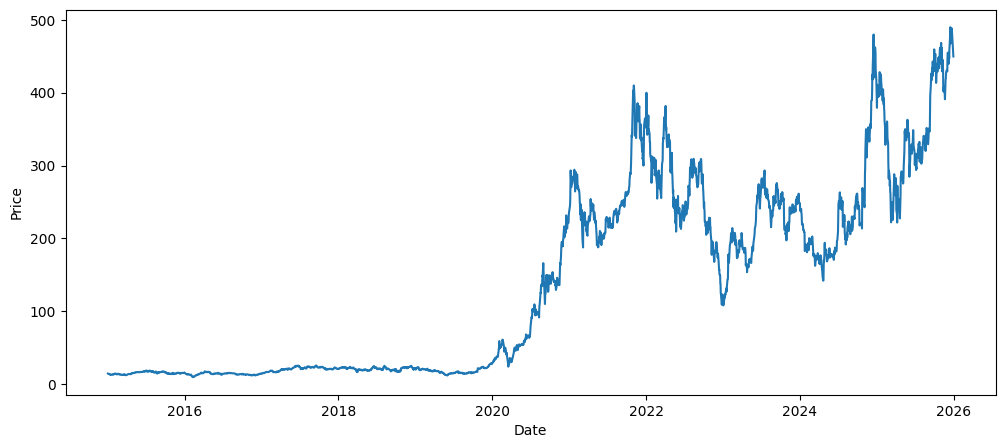

In [6]:
plt.figure(figsize=(12,5))

plt.plot(tsla['Close'])
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [7]:
tsla.columns = [col[0] if isinstance(col, tuple) else col for col in tsla.columns]


In [8]:
tsla.columns


Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [9]:
tsla['MA50'] = tsla['Close'].rolling(window=50).mean()
tsla['MA200'] = tsla['Close'].rolling(window=200).mean()

In [10]:
tsla.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'MA50', 'MA200'], dtype='object')

## 3. Trend Analysis Using Moving Averages

Moving averages help smooth short-term fluctuations and reveal long-term trends.<br>
<b>
• MA50 represents short-term trend  
• MA200 represents long-term trend  </b><br>
• Comparing these with Close price helps observe momentum shifts


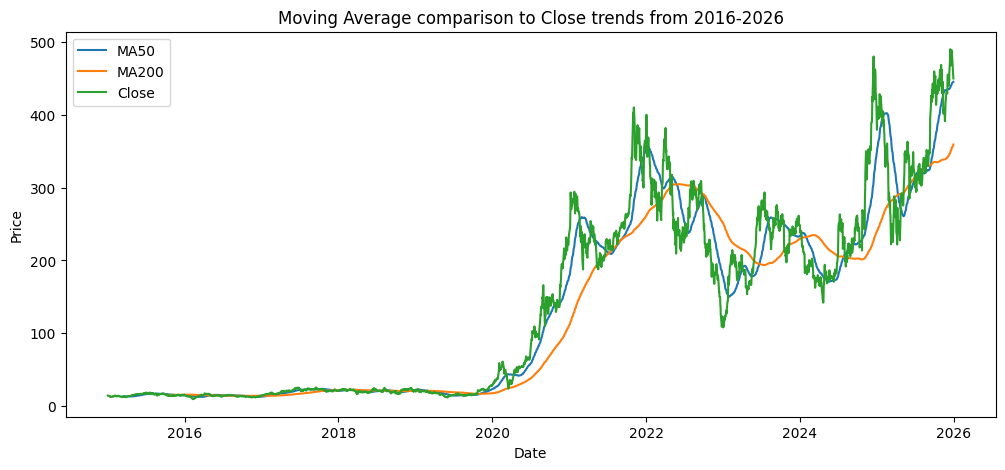

In [11]:
plt.figure(figsize=(12,5))

plt.plot(tsla['MA50'], label='MA50')
plt.plot(tsla['MA200'], label='MA200')
plt.plot(tsla['Close'], label='Close')
plt.legend()
plt.title("Moving Average comparison to Close trends from 2016-2026")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

<p>The 50-day moving average reacts faster to price fluctuations and captures short-term trends, while the 200-day moving average smooths out noise and reflects the long-term trend of Tesla stock.</p>

### Observation

The MA50 closely follows short-term price movements, while MA200 reflects broader market trends. <br>
Crossovers between MA50 and MA200 indicate potential trend reversals.

This visualization confirms strong long-term upward momentum in Tesla stock during the selected period.


## 4. Feature Selection

For this project, we use the 'Close' price as the target variable.

The objective is to predict the next day's closing price based on historical closing prices.


In [12]:
data = tsla[['Close']].values
data.shape

(2766, 1)

The data contains 2,766 daily closing price observations.


In [9]:
print(data)

[[ 14.62066746]
 [ 14.00599957]
 [ 14.08533287]
 ...
 [459.64001465]
 [454.42999268]
 [449.72000122]]


## 5. Data Scaling

LSTM models are sensitive to input scale. 
Therefore, we normalize the data between 0 and 1 using MinMaxScaler.

This helps improve training stability and convergence speed.


In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

data_scaled = scaler.fit_transform(data)

## 6. Sequence Creation for LSTM

LSTM models require sequential input.

We create 60-day sliding windows where:<br>
<b>
• Previous 60 days → Input (X)<br>
• Next day → Target (y)
</b><br>
This allows the model to learn temporal dependencies.


In [14]:
sequence_length = 60
x=[]
y=[]

for i in range(sequence_length,len(data_scaled)):
    x.append(data_scaled[i-sequence_length:i])
    y.append(data_scaled[i])
    
x = np.array(x)
y= np.array(y)

print(x.shape,y.shape)

(2706, 60, 1) (2706, 1)


The resulting dataset contains:<br>
<b>
• 2,706 training samples  
• Each sample contains 60 time steps  
• Each time step has 1 feature (Close price)


## 7. Train-Test Split

The dataset is split chronologically:<br>
<b>
• First 80% → Training set  
• Last 20% → Test set  
</b>
This ensures realistic future prediction evaluation.


In [15]:
split = int(0.8*len(x))

x_train = x[:split]
x_test = x[split:]

y_train = y[:split]
y_test = y[split:]

print(x_train.shape, x_test.shape)

(2164, 60, 1) (542, 60, 1)


## 8. LSTM Model Architecture

Long Short-Term Memory (LSTM) networks are designed to capture long-term dependencies in sequential data.

Unlike traditional neural networks, LSTMs retain information across time steps using gated memory cells, making them suitable for financial time series forecasting.

Model Design:<br><b>
• Two stacked LSTM layers to capture temporal patterns  
• Dropout layers to reduce overfitting  
• Dense output layer to predict next-day closing price  


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense,Dropout

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(60,1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])


D:\PYTHON\envs\ml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Architecture Explanation

1. First LSTM Layer (return_sequences=True):
   Outputs full sequence to allow stacking of another LSTM layer.

2. Second LSTM Layer:
   Extracts higher-level temporal features from the sequence.

3. Dropout (0.2):
   Prevents overfitting by randomly disabling neurons during training.

4. Dense Layer:
   Outputs a single continuous value (next-day closing price).


### Model Compilation

• Optimizer: Adam – adaptive learning rate optimization  
• Loss Function: Mean Squared Error (MSE) – suitable for regression problems  


In [17]:
model.compile(
    optimizer = 'adam',
    loss='mean_squared_error'
)

Mean Squared Error penalizes larger errors more heavily, making it appropriate for financial forecasting tasks.


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

The model contains 30,651 trainable parameters, which is relatively lightweight and suitable for medium-sized time series datasets.


Note: No activation function is used in the output layer because this is a regression task, not classification.


## 9. Model Training

The LSTM model is trained for 20 epochs using:

• Batch size: 32  
• Optimizer: Adam  
• Loss: Mean Squared Error  

Validation data is provided to monitor generalization performance.


In [19]:
history = model.fit(
    x_train,
    y_train,
    epochs = 20,
    batch_size =32,
    validation_data = [x_test, y_test]
)

Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - loss: 0.0084 - val_loss: 0.0031
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0018 - val_loss: 0.0027
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0016 - val_loss: 0.0074
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0014 - val_loss: 0.0028
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0013 - val_loss: 0.0027
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0013 - val_loss: 0.0052
Epoch 7/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0011 - val_loss: 0.0019
Epoch 8/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0011 - val_loss: 0.0024
Epoch 9/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0011 - val_loss: 0.0025
Epoch 10/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0011 - val_loss: 0.0018
Epoch 11/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0012 - val_loss: 0.0014
Epoch 12/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0

### Training Observations
<br>
• Training loss steadily decreases across epochs.<br>
• Validation loss remains relatively stable.<br>
• No severe divergence between training and validation loss is observed.</b><br>

This indicates the model is learning meaningful temporal patterns without significant overfitting.


## 10. Generating Predictions

After training, predictions are generated on the test dataset.<br>

Since the model was trained on scaled data, predictions are transformed back to original price scale using inverse transformation.


In [20]:
predictions = model.predict(x_test)

predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


Inverse scaling ensures predictions are interpretable in real-world price units (USD).


## 11. Actual vs Predicted Price Comparison

The predicted prices are compared against actual market prices to visually assess model performance.


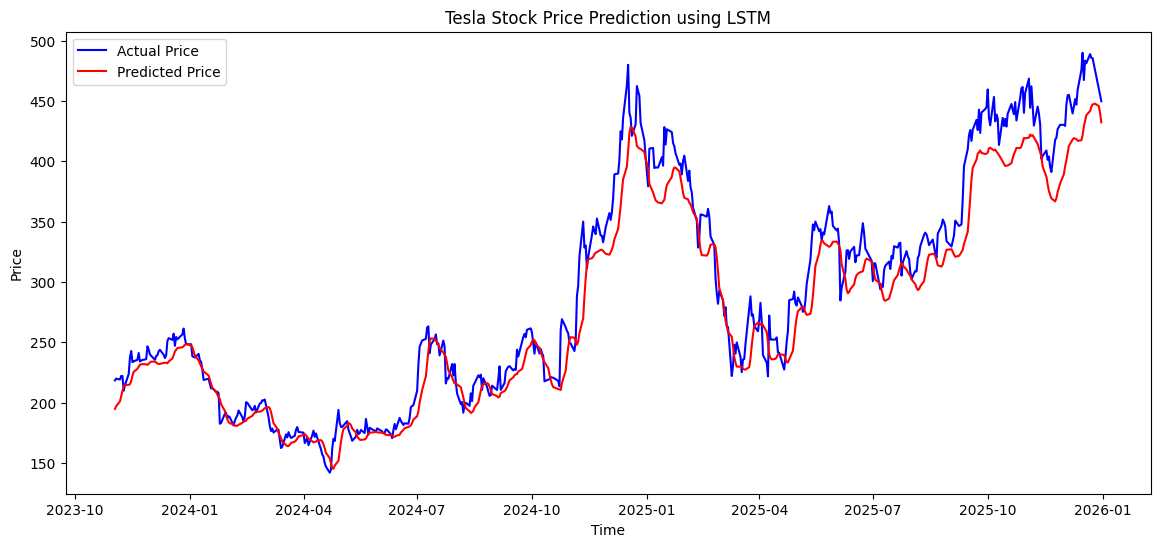

In [26]:
plt.figure(figsize=(14,6))

plt.plot(test_dates,y_test_actual, label="Actual Price", color = 'blue')
plt.plot(test_dates,predictions, label="Predicted Price", color='red')

plt.title("Tesla Stock Price Prediction using LSTM")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()

plt.show()

### Observation

The LSTM model successfully captures:
<b><br>
• Overall trend direction  
• Major upward and downward movements  
• Medium-term momentum shifts  
</b>
However, predictions appear smoother than actual prices, indicating difficulty in capturing sudden volatility spikes.

This smoothing behavior is common in regression-based time series models.


In [23]:
tsla.index

DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13',
               '2015-01-14', '2015-01-15',
               ...
               '2025-12-17', '2025-12-18', '2025-12-19', '2025-12-22',
               '2025-12-23', '2025-12-24', '2025-12-26', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[ns]', name='Date', length=2766, freq=None)

In [25]:
test_dates = tsla.index[len(tsla) - len(y_test_actual):]
print(test_dates)

DatetimeIndex(['2023-11-02', '2023-11-03', '2023-11-06', '2023-11-07',
               '2023-11-08', '2023-11-09', '2023-11-10', '2023-11-13',
               '2023-11-14', '2023-11-15',
               ...
               '2025-12-17', '2025-12-18', '2025-12-19', '2025-12-22',
               '2025-12-23', '2025-12-24', '2025-12-26', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[ns]', name='Date', length=542, freq=None)


## 12. Model Evaluation using RMSE

Root Mean Squared Error (RMSE) measures the average magnitude of prediction errors.

Lower RMSE indicates better forecasting accuracy.


In [28]:
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print("RMSE: ",rmse)

RMSE:  23.714667236040057


### RMSE Result

The model achieved an RMSE of approximately $23.7.

Considering Tesla's price range (~$150–$500), this corresponds to roughly 5–7% relative error, which is reasonable for volatile financial time series.


<p>“On average, how many dollars your prediction is off.”</p>

## 13. Limitations
<br><b>
• The model uses only historical closing prices.<br>
• External factors (news, macroeconomics, earnings reports) are not incorporated.<br>
• LSTM captures patterns but cannot predict unexpected market shocks.


In [30]:
model.save(r"D:\ML Projects\Stock-Price-Forcasting\models\tesla_lstm_model.h5")

In [31]:
import joblib 
joblib.dump(scaler, r"D:\ML Projects\Stock-Price-Forcasting\models\scaler.pkl")

['D:\\ML Projects\\Stock-Price-Forcasting\\models\\scaler.pkl']

## 14. Conclusion

The LSTM model demonstrates strong ability to capture long-term price trends and medium-term fluctuations.

<b>While not suitable for precise short-term trading decisions, the model provides meaningful trend forecasting capability.

Future improvements could include:
<b><br>
• Multivariate features (Volume, High, Low)<br>
• Attention-based models<br>
• Transformer architectures<br>
• Walk-forward validation<br>
